### Import

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.mixture import GaussianMixture

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [4]:
df = pd.read_csv("../data/processed/online_retail.csv")

In [5]:
X = df.drop(columns=['InvoiceDate', 'Invoice', 'StockCode', 'Customer ID'])

In [6]:
customer_features = df.copy()

In [7]:
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=78)
X_pca = pca.fit_transform(X_scaled)

Using PCA to reduce dimensionality so clusters can be visualized.

Also i chose it instead of UMAP or T-SNE, because there're 780k of rows and PCA is the fastest version of dimension reduction.

---

### K-Means analysis

In [8]:
kmeans = KMeans(
    n_clusters=3,
    random_state=78
)

In [9]:
labels = kmeans.fit_predict(X_scaled)

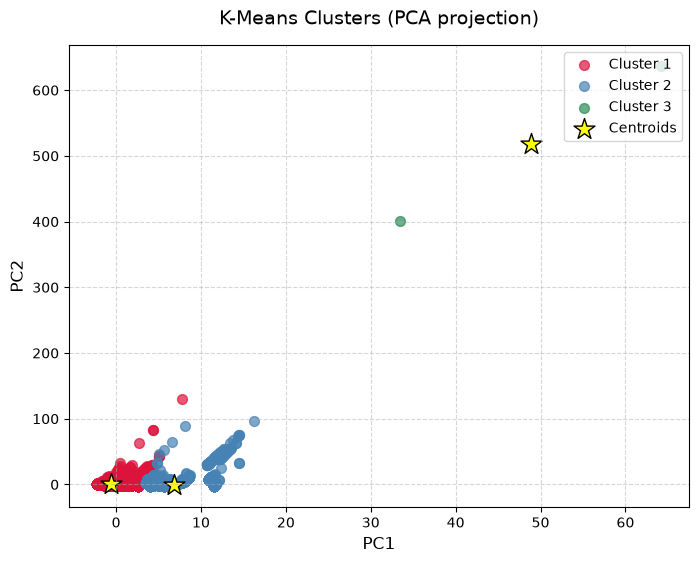

In [10]:
plt.figure(figsize=(8, 6))

colors = ["crimson", "steelblue", "seagreen"]

for cluster_id, color in enumerate(colors):
    mask = labels == cluster_id
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=50,
        c=color,
        alpha=0.7,
        label=f"Cluster {cluster_id + 1}",
    )

centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=250,
    c="yellow",
    marker="*",
    edgecolors="black",
    linewidths=1.0,
    label="Centroids",
)

plt.title("K-Means Clusters (PCA projection)", fontsize=14, pad=15)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.legend(loc="upper right", frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

---

### Inspecting clusters and outliers in it 

Before removing the "outlier" cluster, I'll check how many rows/customers, and whether the extreme values are real.

In [11]:
cluster_summary = (
    df.assign(cluster=labels)
    .groupby("cluster")
    .agg(
        n_rows=("Invoice", "count"),
        n_customers=("Customer ID", "nunique"),
        avg_quantity=("Quantity", "mean"),
        avg_total_revenue=("total_revenue", "mean"),
        avg_num_orders=("num_orders", "mean"),
        avg_recency_days=("recency_days", "mean"),
        avg_cancelled_orders=("sum_cancelled_orders", "mean"),
    )
    .round(2)
)

cluster_summary

,n_rows,n_customers,avg_quantity,avg_total_revenue,avg_num_orders,avg_recency_days,avg_cancelled_orders
cluster,,,,,,,
0,718699,5861,11.65,7909.17,16.73,88.27,3.93
1,60722,23,32.72,173242.36,230.70,2.83,58.75
2,2,2,77605.00,123014.48,7.00,162.50,3.50


In the third cluster i noticed that there're only two customers. They were buying products rarely but with high quantity and revenue.

I'll drop them because they distort my plot so i can't analyze properly other type of clusters.

---

### Dropping the outlier cluster

In [12]:
outlier_cluster = 2

keep_mask = labels != outlier_cluster

df_clean = df[keep_mask].reset_index(drop=True)
X_clean = X[keep_mask].reset_index(drop=True)

X_scaled_clean = X_scaled[keep_mask]
X_pca_clean = X_pca[keep_mask]

print(f"Rows before: {len(df)} -> after: {len(df_clean)}")

Rows before: 779423 -> after: 779421


PCA doesn't reorder rows — `X_pca[i]` still corresponds to `df.iloc[i]`

So I can drop the outlier customers by filtering on the cluster labels, not on the PCA coordinates

In [13]:
kmeans_clean = KMeans(n_clusters=3, random_state=78)
labels_clean = kmeans_clean.fit_predict(X_scaled_clean)

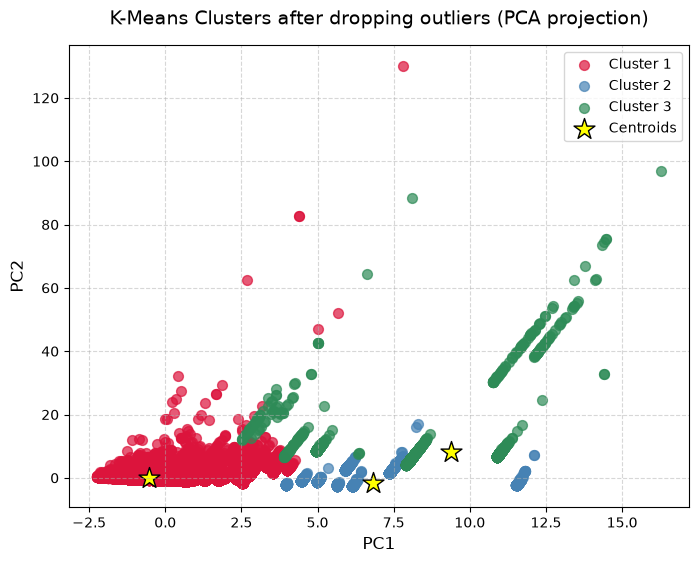

In [14]:
plt.figure(figsize=(8, 6))

colors = ["crimson", "steelblue", "seagreen"]

for cluster_id, color in enumerate(colors):
    mask = labels_clean == cluster_id
    plt.scatter(
        X_pca_clean[mask, 0],
        X_pca_clean[mask, 1],
        s=50,
        c=color,
        alpha=0.7,
        label=f"Cluster {cluster_id + 1}",
    )

centroids_pca = pca.transform(kmeans_clean.cluster_centers_)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=250,
    c="yellow",
    marker="*",
    edgecolors="black",
    linewidths=1.0,
    label="Centroids",
)

plt.title("K-Means Clusters after dropping outliers (PCA projection)", fontsize=14, pad=15)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.legend(loc="upper right", frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

---

### Clusters overlapping fix

In [15]:
customer_cols = [
    "avg_order_value",
    "avg_items_per_order",
    "num_orders",
    "num_products",
    "total_items",
    "avg_unit_price",
    "total_revenue",
    "sum_cancelled_orders",
    "customer_lifetime_days",
    "recency_days",
    "purchase_frequency",
]

cust = df.groupby("Customer ID")[customer_cols].first().reset_index()
print(f"Customers: {len(cust)}  (was {len(df)} rows)")

Customers: 5878  (was 779423 rows)


In [16]:
X_cust = cust.drop(columns=["Customer ID"])
X_cust_scaled = StandardScaler().fit_transform(X_cust)

pca_cust = PCA(n_components=2, random_state=78)
X_cust_pca = pca_cust.fit_transform(X_cust_scaled)

print("Explained variance (2 PCs):", pca_cust.explained_variance_ratio_.round(4).tolist())

Explained variance (2 PCs): [0.364, 0.1663]


- PCA with 2 components explains `only ~52% of variance` — the 2D view squashes real separation.

In [17]:
kmeans_cust = KMeans(n_clusters=3, random_state=78, n_init=10)
labels_cust = kmeans_cust.fit_predict(X_cust_scaled)

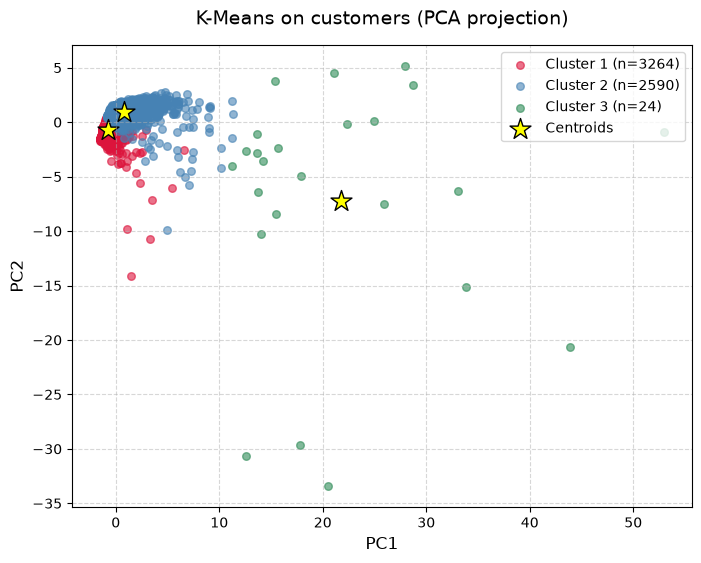

In [18]:
plt.figure(figsize=(8, 6))

colors = ["crimson", "steelblue", "seagreen"]

for cluster_id, color in enumerate(colors):
    mask = labels_cust == cluster_id
    plt.scatter(
        X_cust_pca[mask, 0],
        X_cust_pca[mask, 1],
        s=30,
        c=color,
        alpha=0.6,
        label=f"Cluster {cluster_id + 1} (n={mask.sum()})",
    )

centroids_pca = pca_cust.transform(kmeans_cust.cluster_centers_)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=250,
    c="yellow",
    marker="*",
    edgecolors="black",
    linewidths=1.0,
    label="Centroids",
)

plt.title("K-Means on customers (PCA projection)", fontsize=14, pad=15)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)

plt.legend(loc="upper right", frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

The overlap is mostly a projection and duplication artifact, not bad clustering:

- `68% of rows are exact duplicate feature vectors` (same customer, repeated rows). The dense "one point" is ~944 identical rows.

UMAP / t-SNE would make a prettier picture but are stochastic, slow on 780k rows, and don't fix the row-level duplication, so i won't use it.

---

### Choosing the number of clusters (k)

Before doing it, I need to fix two things in the customer-level data:

1. `Aggregation` — make sure each customer is one row with correct per-customer values.

2. `Skewness` — the features are heavily right-skewed (revenue, quantity, price). I'll use `log1p` for it.

In [19]:
customer_cols = [
    "avg_order_value",
    "avg_items_per_order",
    "num_orders",
    "num_products",
    "total_items",
    "avg_unit_price",
    "total_revenue",
    "sum_cancelled_orders",
    "customer_lifetime_days",
    "recency_days",
    "purchase_frequency",
]

cust = (
    df.groupby("Customer ID")[customer_cols]
    .agg(
        avg_order_value=("avg_order_value", "first"),
        avg_items_per_order=("avg_items_per_order", "first"),
        num_orders=("num_orders", "first"),
        num_products=("num_products", "first"),
        total_items=("total_items", "first"),
        avg_unit_price=("avg_unit_price", "first"),
        total_revenue=("total_revenue", "first"),
        sum_cancelled_orders=("sum_cancelled_orders", "sum"),
        customer_lifetime_days=("customer_lifetime_days", "max"),
        recency_days=("recency_days", "max"),
        purchase_frequency=("purchase_frequency", "first"),
    )
    .reset_index()
)

print(f"Customers: {len(cust)} (was {len(df)} rows)")

Customers: 5878 (was 779423 rows)


In [20]:
X_cust = cust.drop(columns=["Customer ID"])

# handles zeros and tames skew
X_cust_log = np.log1p(X_cust)

print("Skewness before vs after log1p:")
skew_before = X_cust.skew().round(2)
skew_after = X_cust_log.skew().round(2)
print(pd.DataFrame({"before": skew_before, "after": skew_after}).sort_values("before", ascending=False))

Skewness before vs after log1p:
                        before  after
avg_unit_price           51.90   5.01
avg_items_per_order      46.09  -0.62
sum_cancelled_orders     45.78   0.80
avg_order_value          35.28   0.07
total_revenue            25.07   0.27
total_items              21.86  -0.09
num_orders               12.64   1.00
num_products              6.22  -0.28
purchase_frequency        5.80   1.18
recency_days              0.89  -0.62
customer_lifetime_days    0.39  -0.67


In [21]:
X_cust_scaled = StandardScaler().fit_transform(X_cust_log)

pca_cust = PCA(n_components=2, random_state=78)
X_cust_pca = pca_cust.fit_transform(X_cust_scaled)

print("Explained variance (2 PCs):", pca_cust.explained_variance_ratio_.round(4).tolist())
print("Total (2 PCs):", round(pca_cust.explained_variance_ratio_.sum(), 4))

Explained variance (2 PCs): [0.5147, 0.1348]
Total (2 PCs): 0.6496


PCA explains `almost 65%` of variance (was 52%)

---

In [22]:

results = []
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=78, n_init=10)
    lab = km.fit_predict(X_cust_scaled)
    results.append(
        {
            "k": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(X_cust_scaled, lab),
            "davies_bouldin": davies_bouldin_score(X_cust_scaled, lab),
        }
    )

k_results = pd.DataFrame(results).set_index("k")
k_results.round(4)

,inertia,silhouette,davies_bouldin
k,,,
2,42833.2700,0.2994,1.2696
3,35581.2260,0.2436,1.3954
4,31476.2518,0.2290,1.4037
5,28792.6990,0.2309,1.2553


Best inertia score is on 5-k cluster which is expected, because points obviously will be located closer to clusters.

On the other side best k value for silhouette and davies_bouldin scores is 2, but I'll use plots to make sure that I'm right.

---

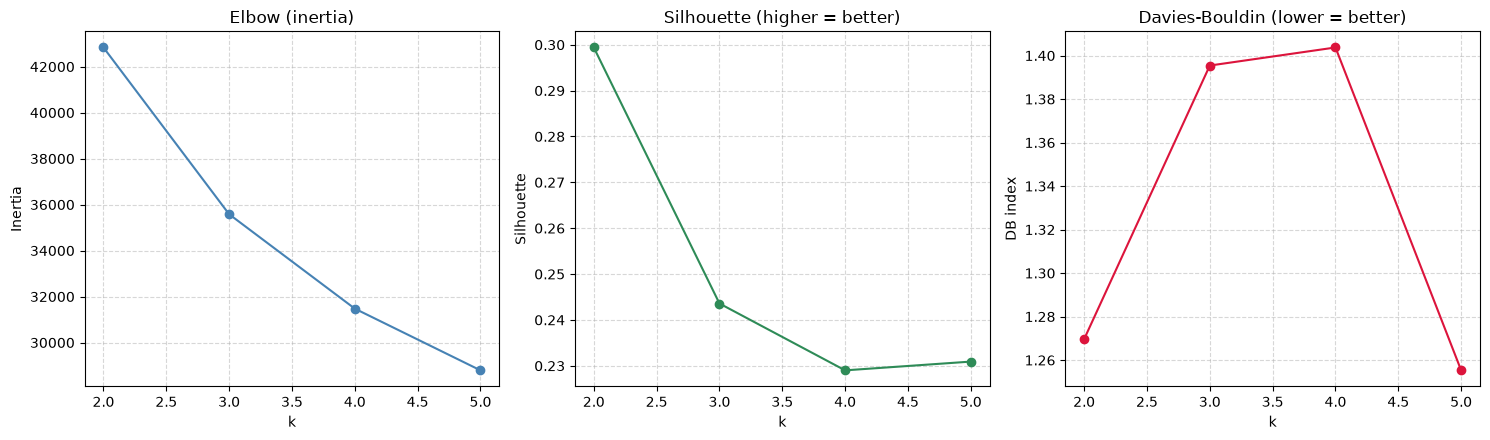

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Elbow
axes[0].plot(k_results.index, k_results["inertia"], marker="o", color="steelblue")
axes[0].set_title("Elbow (inertia)", fontsize=12)
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Silhouette
axes[1].plot(k_results.index, k_results["silhouette"], marker="o", color="seagreen")
axes[1].set_title("Silhouette (higher = better)", fontsize=12)
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
axes[1].grid(True, linestyle="--", alpha=0.5)

# Davies-Bouldin
axes[2].plot(k_results.index, k_results["davies_bouldin"], marker="o", color="crimson")
axes[2].set_title("Davies-Bouldin (lower = better)", fontsize=12)
axes[2].set_xlabel("k")
axes[2].set_ylabel("DB index")
axes[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### Results summary:

| k | inertia | silhouette | Davies-Bouldin |
|---|--------:|-----------:|---------------:|
| 2 | 42,833 | `0.2994` | 1.2696 |
| 3 | 35,581 | 0.2436 | 1.3954 |
| 4 | 31,476 | 0.2290 | 1.4037 |
| 5 | `28,793` | 0.2309 | `1.2553` |

- **Elbow** is around `k=3`, because inertia drops steepest from k=2 to k=3 (42,833 → 35,581), then the drops shrink.

- **Silhouette** highest at `k=2 (0.2994)`

- **Davies-Bouldin:** lowest at `k=5 (1.2553)`, with k=2 close behind (1.2696).

Those three metrics don't agree with eachother and it's ok, I have to find the best tradeoff.

And i decided to use k=3 because it has good elbow + consistent with the earlier analysis.

---

### GMM with BIC/AIC — cross-checking the number of clusters

I want to use GMM so it'll relax both assumptions — each cluster has its own covariance, and points get probabilities of belonging to each cluster instead of hard labels.

GMM gives us a principled way to choose k: `BIC` and `AIC` — lower is better. They penalize model complexity, so they don't just keep improving as k grows (unlike inertia).

In [24]:
gmm_results = []
for k in range(2, 6):
    gmm = GaussianMixture(n_components=k, random_state=78)
    gmm.fit(X_cust_scaled)
    labels_gmm = gmm.predict(X_cust_scaled)
    gmm_results.append(
        {
            "k": k,
            "bic": gmm.bic(X_cust_scaled),
            "aic": gmm.aic(X_cust_scaled),
            "silhouette": silhouette_score(X_cust_scaled, labels_gmm),
            "davies_bouldin": davies_bouldin_score(X_cust_scaled, labels_gmm),
        }
    )

gmm_results = pd.DataFrame(gmm_results).set_index("k")
gmm_results.round(4)

,bic,aic,silhouette,davies_bouldin
k,,,,
2,22267.2400,21231.9994,0.2769,1.2931
3,-28173.0933,-29729.2938,0.2079,2.6288
4,-41759.6599,-43836.8201,0.1326,3.0661
5,-47224.7549,-49822.8750,0.0837,4.0861


Both `BIC/AIC` keep decreasing through k=5. That means GMM would push toward more clusters than K-Means found.

So the data has finer structure than 3 segments / the log-normal assumption fits better with more components.
- Well it doesn't invalidate k=3, because BIC/AIC and K-Means metrics measure different things. So the "right k" depends on the algorithm's assumptions.

---

### Agglomerative clustering — visual confirmation

Hierarchical clustering gives a dendrogram — a tree showing how customers merge into clusters. It's a visual sanity check on whether 3 clusters is a natural cut.

It's O(n²) in memory / time, so we subsample to 1,000 customers (cause the dendrogram would be unreadable with 5,878 leaves).

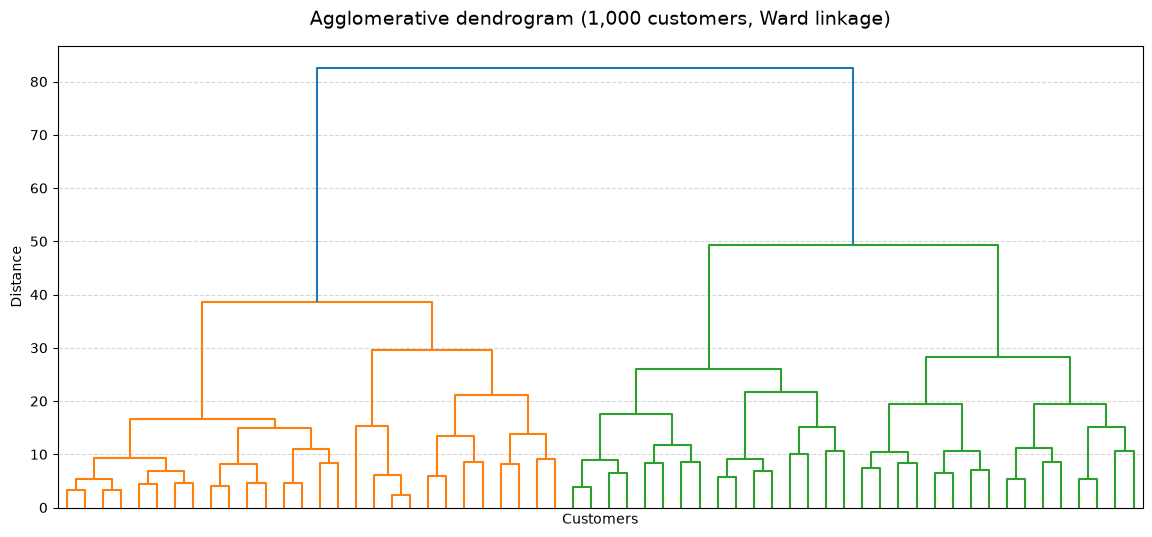

In [32]:
np.random.seed(78)

sample_idx = np.random.choice(len(X_cust_scaled), size=1000, replace=False)
X_sample = X_cust_scaled[sample_idx]

Z = linkage(X_sample, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode="level", p=5, no_labels=True)

plt.title("Agglomerative dendrogram (1,000 customers, Ward linkage)", fontsize=14, pad=15)
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [35]:
labels_agglo = fcluster(Z, t=3, criterion="maxclust")

km_sample = KMeans(n_clusters=3, random_state=78, n_init=10)
labels_km_sample = km_sample.fit_predict(X_sample)

print("Silhouette on subsample:")
print(f"  Agglomerative (k=3): {silhouette_score(X_sample, labels_agglo):.4f}")
print(f"  K-Means (k=3): {silhouette_score(X_sample, labels_km_sample):.4f}")

print(f"\nAdjusted Rand Index (agreement): {adjusted_rand_score(labels_km_sample, labels_agglo):.4f}")

Silhouette on subsample:
  Agglomerative (k=3): 0.2030
  K-Means (k=3): 0.2420

Adjusted Rand Index (agreement): 0.5721


- The **dendrogram** shows the merge structure — look for where the tree has long vertical branches, which indicate natural cluster boundaries.

- **Adjusted Rand Index (ARI)** measures agreement between two clusterings (e.g. 1.0 = identical). If agglomerative and K-Means largely agree at k=3, that's strong evidence the 3-cluster structure is real, not an artifact of the algorithm.

---

### Final model with chosen k

In [27]:
best_k = 3 

kmeans_final = KMeans(n_clusters=best_k, random_state=78, n_init=10)
labels_final = kmeans_final.fit_predict(X_cust_scaled)

print("Cluster sizes:")
print(pd.Series(labels_final).value_counts().sort_index())

Cluster sizes:
0    2000
1    2516
2    1362
Name: count, dtype: int64


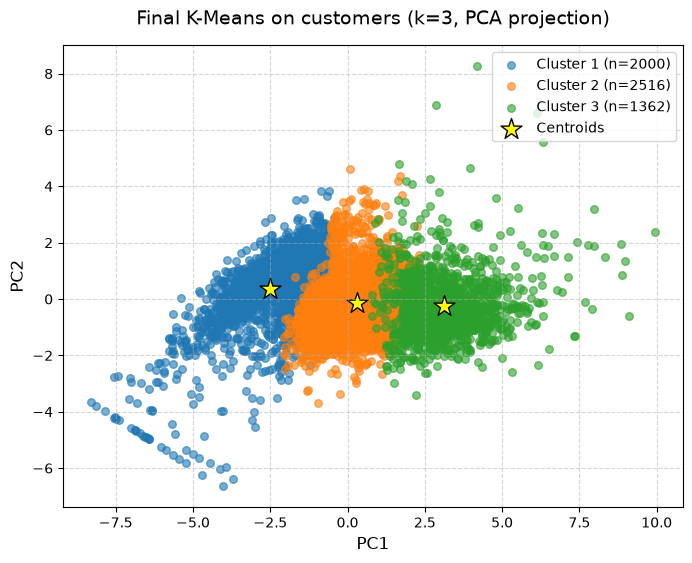

In [28]:
plt.figure(figsize=(8, 6))

cmap = plt.cm.tab10

for cluster_id in range(best_k):
    mask = labels_final == cluster_id
    plt.scatter(
        X_cust_pca[mask, 0],
        X_cust_pca[mask, 1],
        s=30,
        c=[cmap(cluster_id)],
        alpha=0.6,
        label=f"Cluster {cluster_id + 1} (n={mask.sum()})",
    )

centroids_pca = pca_cust.transform(kmeans_final.cluster_centers_)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=250,
    c="yellow",
    marker="*",
    edgecolors="black",
    linewidths=1.0,
    label="Centroids",
)

plt.title(f"Final K-Means on customers (k={best_k}, PCA projection)", fontsize=14, pad=15)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.legend(loc="upper right", frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

In [29]:
final_summary = (
    cust.assign(cluster=labels_final)
    .groupby("cluster")
    .agg(
        n_customers=("Customer ID", "count"),
        avg_total_revenue=("total_revenue", "mean"),
        avg_num_orders=("num_orders", "mean"),
        avg_quantity_per_order=("avg_items_per_order", "mean"),
        avg_recency_days=("recency_days", "mean"),
        avg_cancelled_orders=("sum_cancelled_orders", "mean"),
    )
    .round(2)
)

final_summary

,n_customers,avg_total_revenue,avg_num_orders,avg_quantity_per_order,avg_recency_days,avg_cancelled_orders
cluster,,,,,,
0,2000,336.26,1.37,141.61,348.87,3.65
1,2516,1237.38,4.17,238.92,159.63,46.66
2,1362,9976.85,17.42,607.75,57.40,4600.19


---

### Summary

Based on the final results there are three distinct customer segments:

**Cluster 1 — Occasional bulk buyers (34% of customers)**

Customers who buy **expensive products in bulk but very rarely** — on average once per ~349 days (1.4 orders total). They spend the most per item (avg unit price £18.7, the highest of all clusters) and rarely cancel (3.7 cancelled orders).

> **Example:** a small business that orders premium equipment once a year — e.g. a design studio buying high-end monitors, or a clinic purchasing premium office equipment for the whole team.

**Cluster 2 — Everyday value shoppers (43% of customers)**

The **largest segment**: regular customers buying **cheap products (avg unit price £3.2)** fairly often — once per ~160 days (4.2 orders). They cancel moderately (46.7 orders) and spend ~£1,237 in total.

> **Example:** a household buying everyday goods — e.g. groceries, stationery, or home essentials — restocking when they run out.

**Cluster 3 — High-volume resellers (23% of customers)**

The **biggest spenders**: they order very often (17.4 orders, once per ~57 days), buy huge quantities per order (608 items, ~£812 per order), and generate ~£9,977 in revenue — **8× more than Cluster 2**. They also cancel the most (4,600 cancelled orders), which is typical for bulk operations.

> **Example:** a reseller or wholesaler stocking up inventory — e.g. a shop owner buying wholesale goods to resell, or a distributor ordering stock in bulk.

**Key takeaway:** the three clusters form a clear value ladder — occasional premium buyers → regular value shoppers → high-volume resellers. The resellers drive the bulk of revenue (8× the middle segment) and are the most valuable to retain, despite their high cancellation rate.

---